## Downloading Dataset from Kaggle

In [1]:
# import kagglehub

# path = kagglehub.dataset_download("endofnight17j03/imdb-movies-review")

# print("Path to dataset files:", path)

## Imports

In [2]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import matplotlib.pyplot as plt

## 1. Data Pre-processing

In [3]:
# Loading Dataset
df = pd.read_csv(r"./dataset/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# Filtering Dataset
df['review'] = df['review'].str.replace("<br />", "")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Formatting Data
for cols in df.columns:
    df[cols] = df[cols].str.lower()

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


## 2. Feature Extraction

In [6]:
# [Text Feature Extraction] Applying TF-IDF => Converting text -> numerical features
tfidf_vectorizer = TfidfVectorizer(min_df=3, ngram_range=(1,2))

X_tfidf = tfidf_vectorizer.fit_transform(df["review"])
X_tfidf.shape

(50000, 452985)

## 3. Data Splitting & Model Building

In [7]:
# Splitting Data
X = X_tfidf
y = df['sentiment'].map({"positive": 1, "negative": 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
lr = LogisticRegression(max_iter=1000)
nb = MultinomialNB()
svm = LinearSVC()

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "SVM": svm
}

# Training
for _, model in models.items():
    model.fit(X_train, y_train)

## 4. Model Evaluation

In [8]:
# Result
results = {
    "Model": [],
    "Accuracy": [],
    "Precision Score": [],
    "Recall Score": [],
    "F1 Score": []
}

for name, model in models.items():
    # Predict
    y_pred = model.predict(X_test)

    # Score Calculation
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rcl = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results["Model"].append(name)
    results["Accuracy"].append(round(acc, 2))
    results["Precision Score"].append(round(pre, 2))
    results["Recall Score"].append(round(rcl, 2))
    results["F1 Score"].append(round(f1, 2))

    # Displaying
    print(f"\n{name} Model's Performance")
    print(f"Accuracy: {acc:.2f}")
    print(f"Precision: {pre:.2f}")
    print(f"Recall: {rcl:.2f}")
    print(f"F1: {f1:.2f}")

print("\nPerformance Matrix")
results_df = pd.DataFrame(results)
print(results_df)


Logistic Regression Model's Performance
Accuracy: 0.91
Precision: 0.90
Recall: 0.92
F1: 0.91

Naive Bayes Model's Performance
Accuracy: 0.89
Precision: 0.91
Recall: 0.87
F1: 0.89

SVM Model's Performance
Accuracy: 0.92
Precision: 0.91
Recall: 0.93
F1: 0.92

Performance Matrix
                 Model  Accuracy  Precision Score  Recall Score  F1 Score
0  Logistic Regression      0.91             0.90          0.92      0.91
1          Naive Bayes      0.89             0.91          0.87      0.89
2                  SVM      0.92             0.91          0.93      0.92


## 5. Graph Plotting

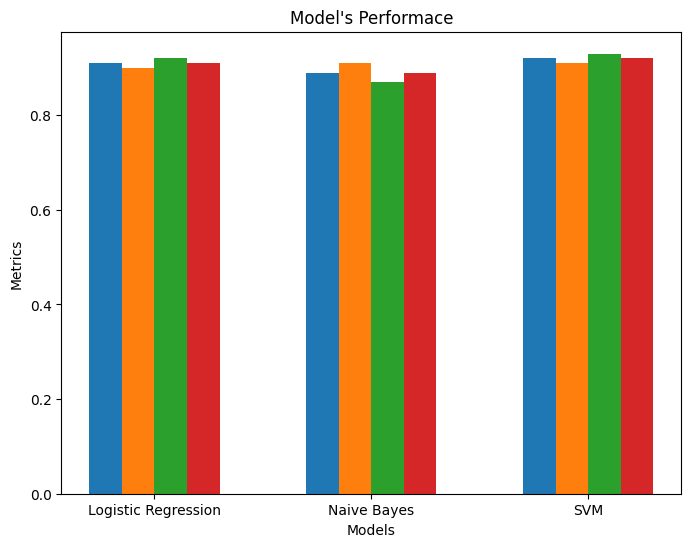

In [9]:
models = list(results_df["Model"])
metrics = ["Accuracy", "Precision Score", "Recall Score", "F1 Score"]

x = list(range(len(models)))
width = 0.15

plt.figure(figsize=(8,6))

for i, metric in enumerate(metrics):
    position = [p + (i * width) for p in x]
    plt.bar(position, results_df[metric], width=width, label=metric)

mid_pos = [p + width * 1.5 for p in x]
plt.xticks(mid_pos, models)

plt.xlabel("Models")
plt.ylabel("Metrics")
plt.title("Model's Performace")
plt.show()
